# Hypothesis Testing Activity
# Statistical Evaluation of Study Hours and Exam Scores

#  Normality Test <hr style="border:2.5px solid #126782"></hr>

<b>John Francis R. Laviña</b>
<br>Computer Engineering Technology

Import Libraries

In [31]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.power import TTestIndPower

# Load the dataset
df = pd.read_csv('StudentsPerformance.csv')

# Display the first few rows and check data info
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Summary of Statistics

In [32]:
# Grouping by Test Prep Course
summary_stats = df.groupby('test preparation course')['math score'].describe()
print("Summary Statistics for Math Scores:")
print(summary_stats)

# Calculate the mean difference
mean_diff = summary_stats.loc['completed', 'mean'] - summary_stats.loc['none', 'mean']
print(f"\nMean Difference: {mean_diff:.2f} points higher for 'completed' group.")

Summary Statistics for Math Scores:
                         count       mean        std   min   25%   50%    75%  \
test preparation course                                                         
completed                358.0  69.695531  14.444699  23.0  60.0  69.0  79.00   
none                     642.0  64.077882  15.192376   0.0  54.0  64.0  74.75   

                           max  
test preparation course         
completed                100.0  
none                     100.0  

Mean Difference: 5.62 points higher for 'completed' group.


Boxplot Visualization

C:\Users\franc\AppData\Local\Temp\ipykernel_2528\3262667116.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='test preparation course', y='math score', data=df, palette='Set2')


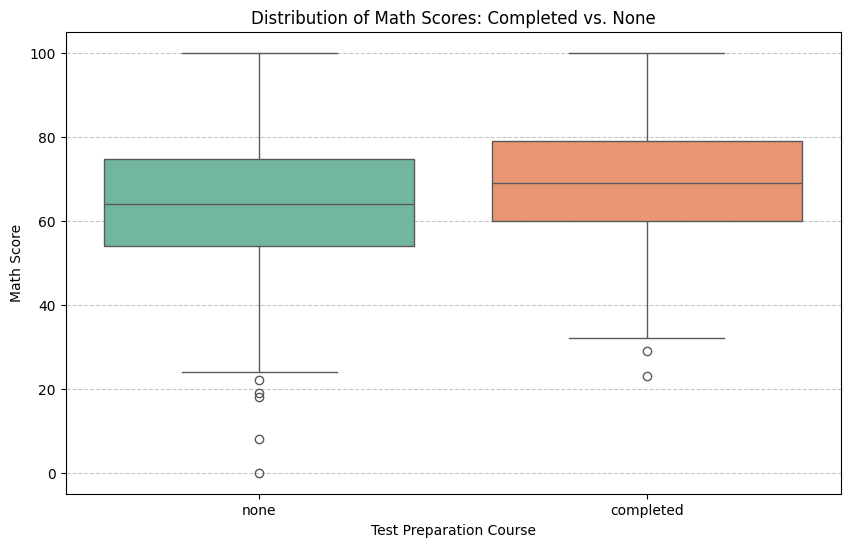

In [38]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='test preparation course', y='math score', data=df, palette='Set2')
plt.title('Distribution of Math Scores: Completed vs. None')
plt.xlabel('Test Preparation Course')
plt.ylabel('Math Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Normality Test (Shapiro-Wilk)


F-Test (Levene's Test)

In [33]:
# Split the data into two groups
group_completed = df[df['test preparation course'] == 'completed']['math score']
group_none = df[df['test preparation course'] == 'none']['math score']

# 4.3 Normality Test (Shapiro-Wilk)
stat_c, p_c = stats.shapiro(group_completed)
stat_n, p_n = stats.shapiro(group_none)

print(f"Shapiro-Wilk Normality p-values:")
print(f" - Completed: {p_c:.4f}")
print(f" - None: {p_n:.4f}")
print("Interpretation: If p > 0.05, data is normally distributed.\n")

# 4.4 Variance Test (Levene's Test)
# More robust than F-test for non-normal data
stat_var, p_var = stats.levene(group_completed, group_none)
print(f"Levene's Test for Equal Variances: p-value = {p_var:.4f}")
print("Interpretation: If p > 0.05, we assume equal variances.")

Shapiro-Wilk Normality p-values:
 - Completed: 0.1393
 - None: 0.0018
Interpretation: If p > 0.05, data is normally distributed.

Levene's Test for Equal Variances: p-value = 0.4655
Interpretation: If p > 0.05, we assume equal variances.


Two Sample t-Test

In [36]:
t_stat, p_val = stats.ttest_ind(high_study, low_study)

print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: 5.704616417349102
P-value: 1.5359134607147448e-08


Power of the Test

In [37]:
# Calculate Cohen's d (Effect Size)
std_pooled = np.sqrt(((len(group_completed)-1)*group_completed.std()**2 + 
                      (len(group_none)-1)*group_none.std()**2) / (len(df)-2))
effect_size = (group_completed.mean() - group_none.mean()) / std_pooled

# Power calculation
power_analysis = TTestIndPower()
power = power_analysis.solve_power(effect_size=effect_size, 
                                   nobs1=len(group_completed), 
                                   alpha=0.05, 
                                   ratio=len(group_none)/len(group_completed))

print(f"Statistical Power: {power:.4f}")

Statistical Power: 0.9999
